### Split data and standardize features

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Split features and labels
X = df.drop(columns=["price_range"])
y = df["price_range"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Create summary table
standardization_summary = pd.DataFrame({
    "Original Mean": X.mean(),
    "Original Std": X.std(),
    "Standardized Mean": X_scaled_df.mean(),
    "Standardized Std": X_scaled_df.std()
})

# Round for report
standardization_summary = standardization_summary.round(4)

standardization_summary.head(10).T

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores
Original Mean,1238.5185,0.4950,1.5223,0.5095,4.3095,0.5215,32.0465,0.5018,140.2490,4.5205
Original Std,439.4182,0.5001,0.8160,0.5000,4.3414,0.4997,18.1457,0.2884,35.3997,2.2878
Standardized Mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000
Standardized Std,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003,1.0003


### PCA to 2 dimensions and visualize true labels

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA feature shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance ratio:", pca.explained_variance_ratio_.sum())

PCA feature shape: (2000, 2)
Explained variance ratio: [0.08386288 0.08112475]
Total explained variance ratio: 0.16498762894281954


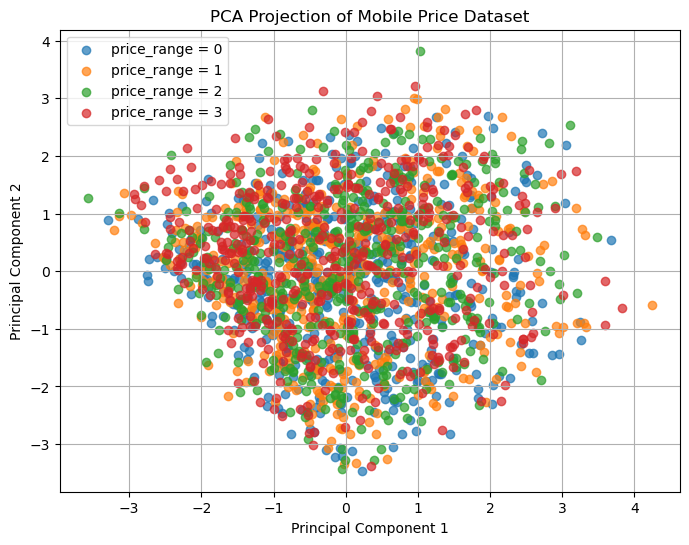

In [16]:
plt.figure(figsize=(8, 6))

for label in sorted(y.unique()):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"price_range = {label}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mobile Price Dataset")
plt.legend()
plt.grid(True)
plt.show()

### K-means using all features

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

# K-means using all standardized features
kmeans_all = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_all = kmeans_all.fit_predict(X_scaled)

# Clustering performance
ari_all = adjusted_rand_score(y, clusters_all)

print("Clustering performance of K-means using all features")
print("Clustering performance: Adjusted Rand Index =", round(ari_all, 4))

Clustering performance of K-means using all features
Clustering performance: Adjusted Rand Index = 0.006


c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


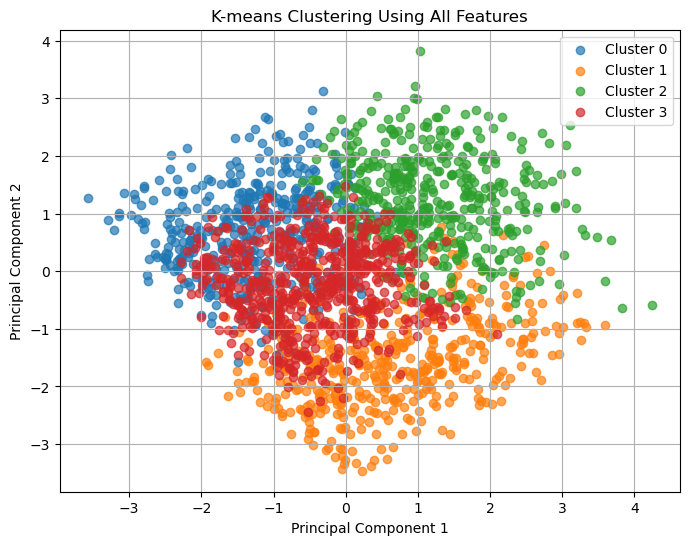

In [19]:
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(clusters_all)):
    plt.scatter(
        X_pca[clusters_all == cluster, 0],
        X_pca[clusters_all == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering Using All Features")
plt.legend()
plt.grid(True)
plt.show()

### K-means using PCA 2D features

In [25]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y, clusters_pca)

print("Clustering performance of K-means using PCA 2D features")
print("Clustering performance: Adjusted Rand Index =", round(ari_pca, 4))

Clustering performance of K-means using PCA 2D features
Clustering performance: Adjusted Rand Index = 0.0017


c:\Users\lee\anaconda3\envs\3.11.3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


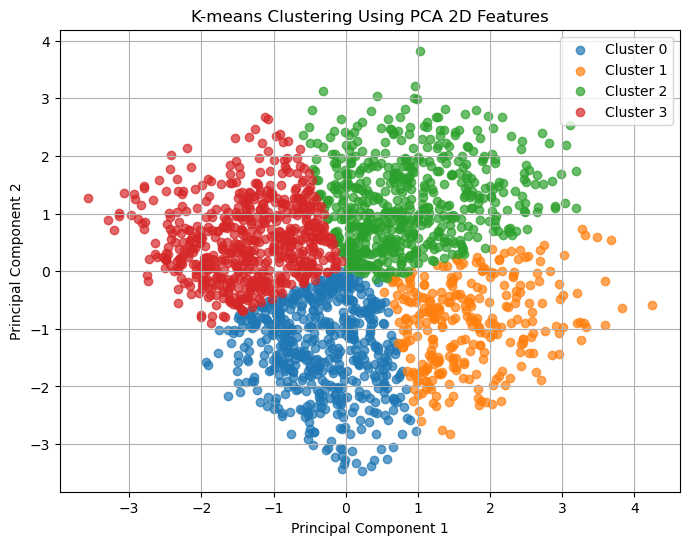

In [24]:
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(clusters_pca)):
    plt.scatter(
        X_pca[clusters_pca == cluster, 0],
        X_pca[clusters_pca == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering Using PCA 2D Features")
plt.legend()
plt.grid(True)
plt.show()

### table

In [8]:
q4_results = pd.DataFrame({
    "Method": [
        "K-means using all standardized features",
        "K-means using PCA 2D features"
    ],
    "Adjusted Rand Index": [
        ari_all,
        ari_pca
    ]
})

q4_results

,Method,Adjusted Rand Index
0,K-means using all standardized features,0.005962
1,K-means using PCA 2D features,0.001695
